In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/SuperStoreOrders.csv')

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [7]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format= 'mixed',
    dayfirst=True
)

In [8]:
df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format= 'mixed',
    dayfirst=True
)

In [12]:
df[df['sales'].str.contains(r"[^0-9.]",regex=True)]['sales'].head(10)

27     1,648
43     3,029
58     2,574
83     2,479
84     2,174
100    2,875
125    1,384
126    1,323
163    1,200
173    1,326
Name: sales, dtype: str

In [13]:
df['sales'] = df['sales'].str.replace(',','')

In [15]:
df[df['sales'].str.contains(r"[0-9.]",regex=True)]['sales'].head(10)

0    408
1    120
2     66
3     45
4    114
5     55
6    314
7    276
8    912
9    667
Name: sales, dtype: str

In [18]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  int64         
 15  quantity     

In [20]:
df['sales'].describe()

count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

In [27]:
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

In [26]:
df.groupby('category')['profit'].sum().sort_values(ascending=False)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

In [30]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780,2013-05-15 20:42:42.745174,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931


In [33]:
df[[
    'sales',
    'quantity',	
    'discount',	
    'profit',
    'shipping_cost'	
]
].corr(numeric_only=True)

,sales,quantity,discount,profit,shipping_cost
sales,1.000000,0.313580,-0.086728,0.485944,0.768075
quantity,0.313580,1.000000,-0.019875,0.104743,0.272649
discount,-0.086728,-0.019875,1.000000,-0.316375,-0.079056
profit,0.485944,0.104743,-0.316375,1.000000,0.357033
shipping_cost,0.768075,0.272649,-0.079056,0.357033,1.000000


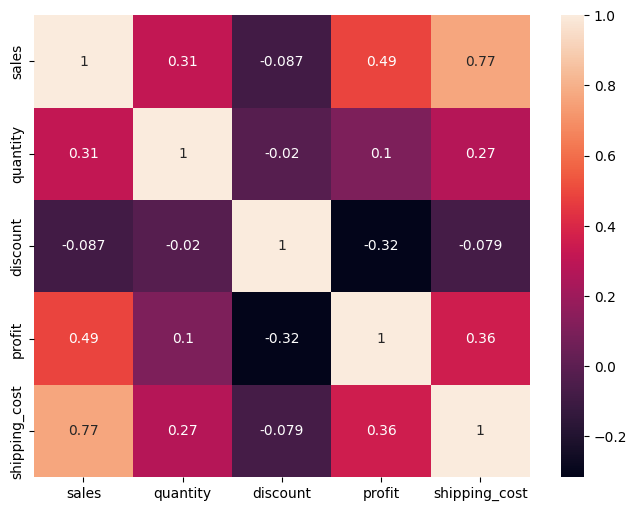

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
        'sales',
        'quantity',	
        'discount',	
        'profit',
        'shipping_cost'	
        ]
    ].corr(),
    annot=True
)

plt.show()


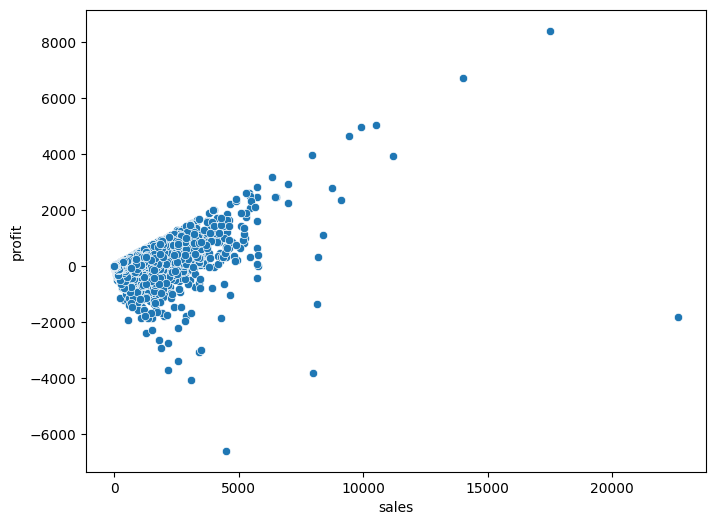

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit"
)

plt.show()

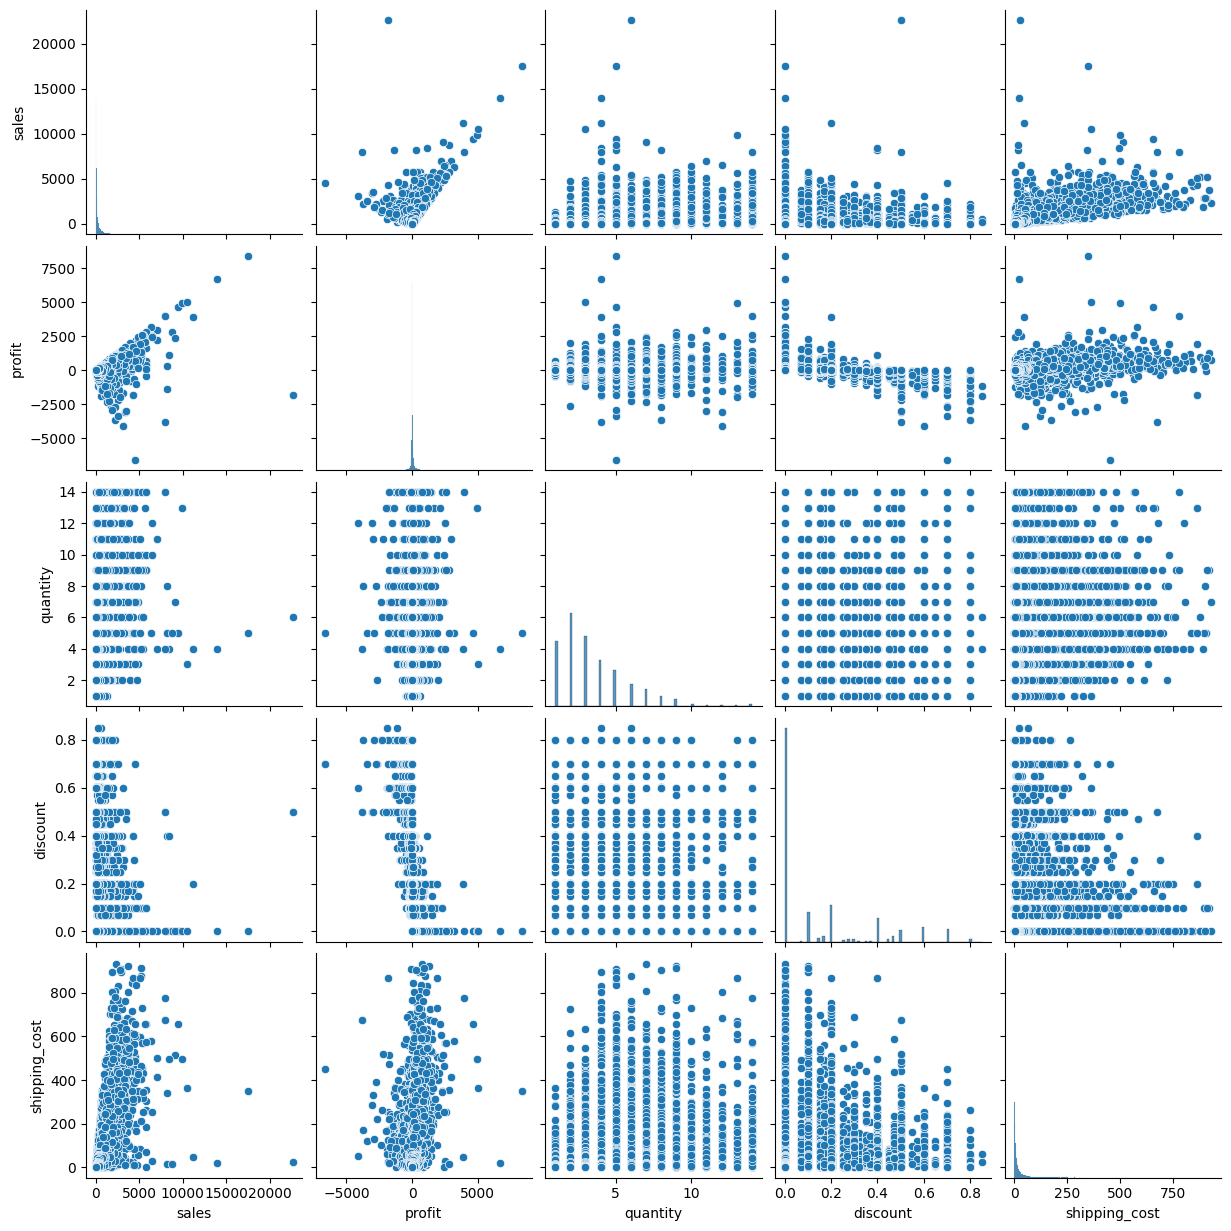

In [38]:
sns.pairplot(
    df[
        [
            "sales",
            "profit",
            "quantity",
            "discount",
            "shipping_cost"
        ]
    ]
)

plt.show()

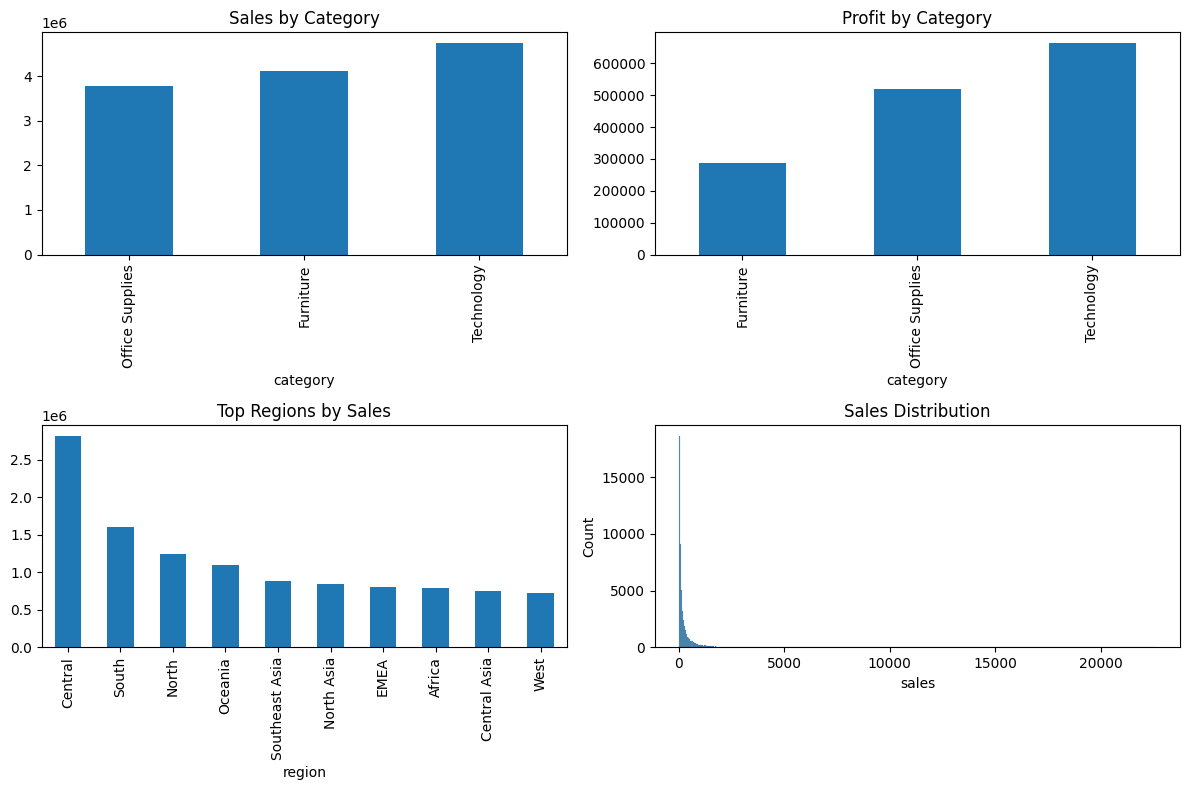

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Category Sales
df.groupby("category")["sales"].sum().sort_values().plot(
    kind="bar",
    ax=axes[0,0]
)
axes[0,0].set_title("Sales by Category")

# Category Profit
df.groupby("category")["profit"].sum().sort_values().plot(
    kind="bar",
    ax=axes[0,1]
)
axes[0,1].set_title("Profit by Category")

# Region Sales
df.groupby("region")["sales"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar",
    ax=axes[1,0]
)
axes[1,0].set_title("Top Regions by Sales")

# Sales Distribution
sns.histplot(df["sales"], ax=axes[1,1])
axes[1,1].set_title("Sales Distribution")

plt.tight_layout()
plt.show()

<Axes: xlabel='sales', ylabel='profit'>

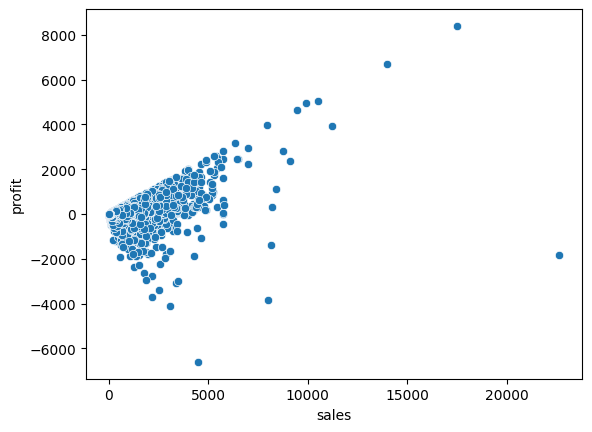

In [40]:
sns.scatterplot(data=df, x="sales", y="profit")